## 1. Importación de librerías

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imageio
from scipy import ndimage

## 2. Carga y visualización de la imagen original

Cargamos una imagen RGB de un animal en vía de extinción y la mostramos.

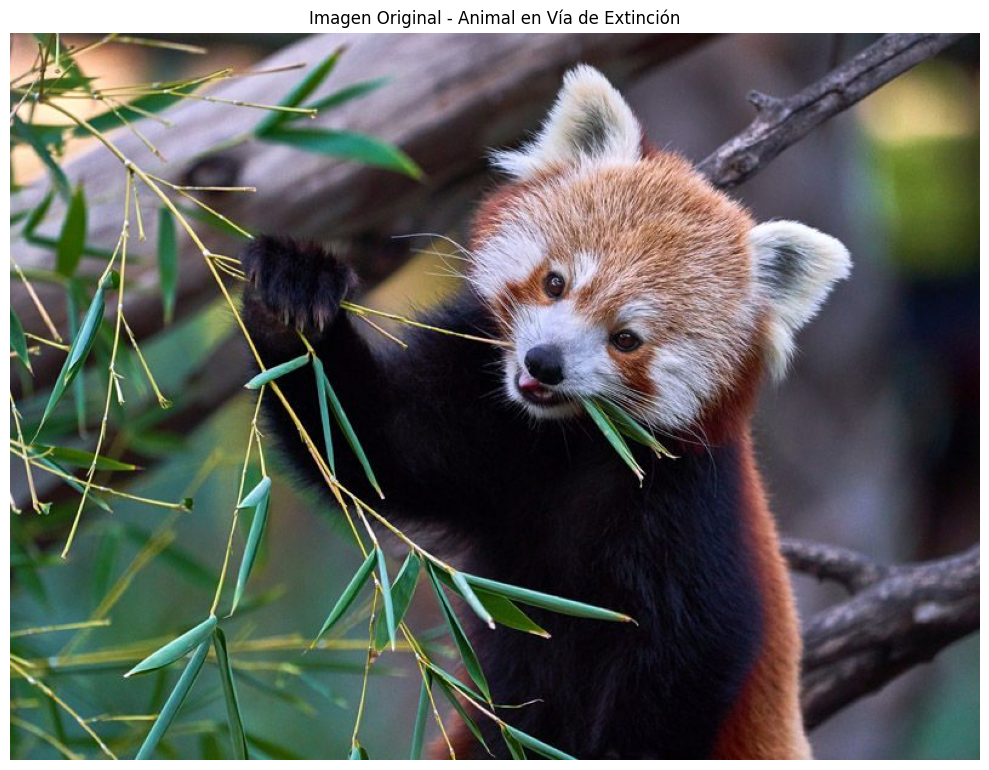

Dimensiones de la imagen: (600, 800, 3)


In [3]:
# Cargar la imagen (asegúrate de colocar una imagen en la carpeta data/)
# Ejemplo: imagen de un panda, tigre, rinoceronte, etc.
imagen_path = 'data/animal.jpg'  # Reemplazar con el nombre de tu imagen
imagen_bgr = cv2.imread(imagen_path)
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

# Visualizar la imagen original
plt.figure(figsize=(10, 8))
plt.imshow(imagen_rgb)
plt.title('Imagen Original - Animal en Vía de Extinción')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Dimensiones de la imagen: {imagen_rgb.shape}")

## 3. Aplicación de filtros básicos

### 3.1 Filtro de suavizado / desenfoque

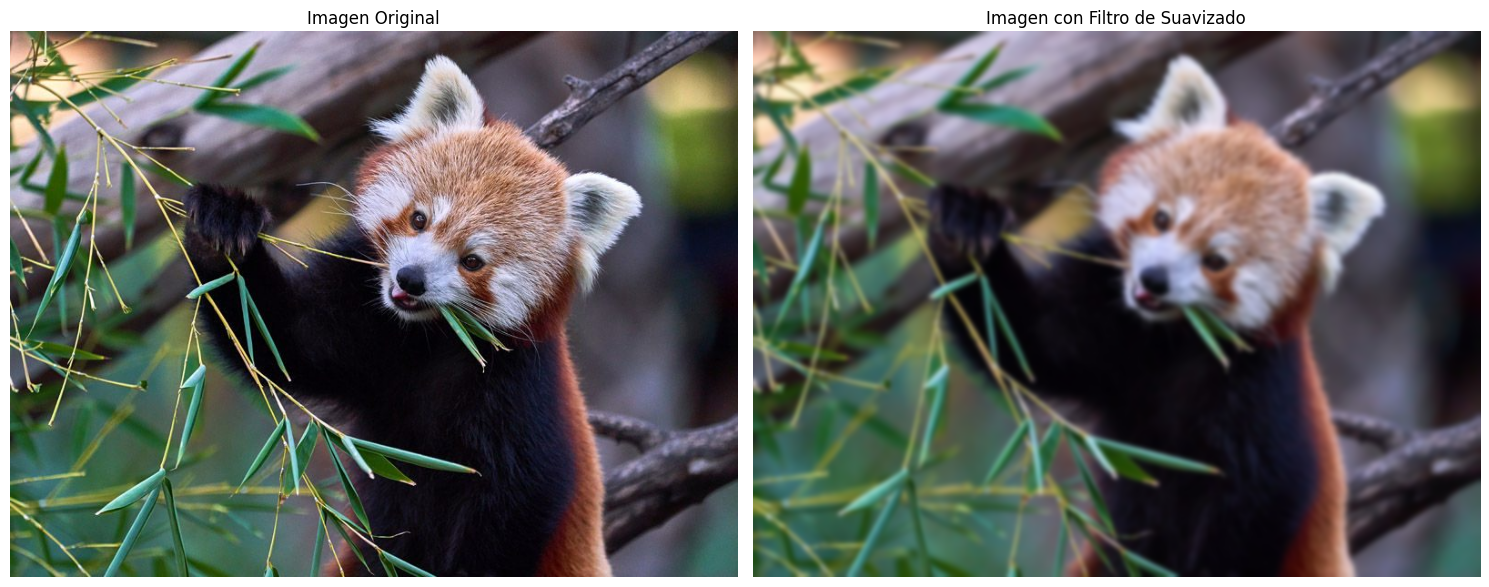

Efecto visual observado:
El filtro de suavizado reduce el ruido y los detalles finos de la imagen,
creando un efecto de desenfoque que hace que la imagen se vea más suave
y menos nítida. Los bordes y texturas se atenúan.


In [4]:
# Aplicar filtro Gaussiano para suavizado
imagen_suavizada = cv2.GaussianBlur(imagen_rgb, (15, 15), 0)

# Visualizar resultado
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(imagen_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_suavizada)
plt.title('Imagen con Filtro de Suavizado')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Efecto visual observado:")
print("El filtro de suavizado reduce el ruido y los detalles finos de la imagen,")
print("creando un efecto de desenfoque que hace que la imagen se vea más suave")
print("y menos nítida. Los bordes y texturas se atenúan.")

### 3.2 Filtro de realce de bordes

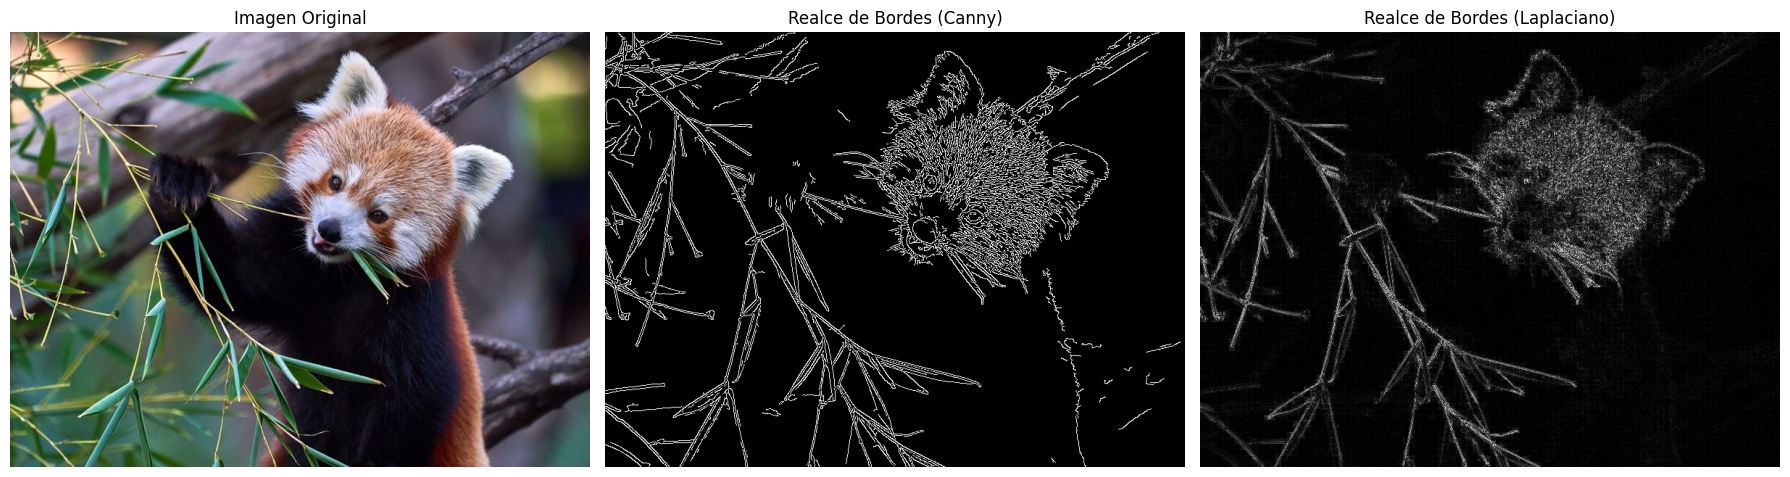

Efecto visual observado:
Los filtros de realce de bordes destacan las transiciones abruptas de intensidad,
resaltando los contornos y límites entre diferentes regiones de la imagen.
El filtro Canny muestra bordes más limpios y definidos, mientras que el Laplaciano
captura detalles más finos pero también puede incluir más ruido.


In [5]:
# Convertir a escala de grises para mejor detección de bordes
imagen_gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)

# Aplicar el filtro de Canny para detección de bordes
bordes = cv2.Canny(imagen_gris, 100, 200)

# Aplicar filtro Laplaciano como alternativa
laplaciano = cv2.Laplacian(imagen_gris, cv2.CV_64F)
laplaciano = np.uint8(np.absolute(laplaciano))

# Visualizar resultados
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(imagen_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(bordes, cmap='gray')
plt.title('Realce de Bordes (Canny)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplaciano, cmap='gray')
plt.title('Realce de Bordes (Laplaciano)')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Efecto visual observado:")
print("Los filtros de realce de bordes destacan las transiciones abruptas de intensidad,")
print("resaltando los contornos y límites entre diferentes regiones de la imagen.")
print("El filtro Canny muestra bordes más limpios y definidos, mientras que el Laplaciano")
print("captura detalles más finos pero también puede incluir más ruido.")

## 4. Visualización de canales de color

Separamos la imagen en sus tres canales RGB y los visualizamos individualmente.

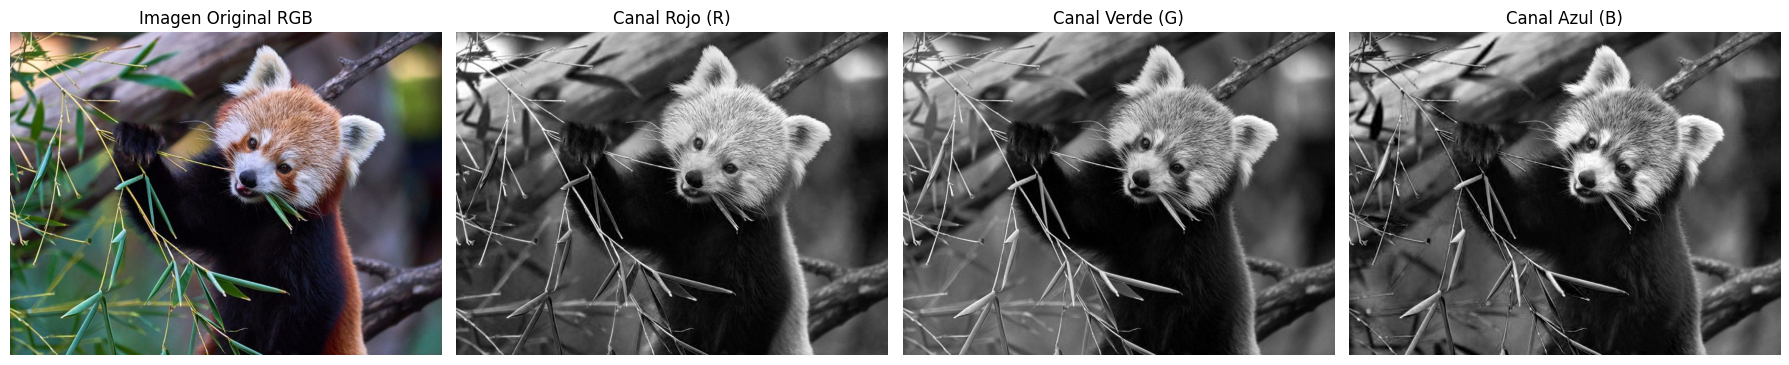

Explicación de los canales:

Canal Rojo (R): Las zonas más claras corresponden a áreas con mayor
concentración de tonos rojos. En animales con pelaje marrón o naranja,
estas áreas aparecerán más brillantes.

Canal Verde (G): Destaca las áreas con tonalidades verdes. En la vegetación
o fondos naturales, este canal mostrará mayor intensidad.

Canal Azul (B): Las zonas más claras indican mayor presencia de azul.
En cielos o fondos acuáticos, este canal será más brillante.

Las áreas oscuras en cada canal indican baja presencia de ese color específico.


In [6]:
# Separar canales
canal_r = imagen_rgb[:, :, 0]
canal_g = imagen_rgb[:, :, 1]
canal_b = imagen_rgb[:, :, 2]

# Visualizar canales en escala de grises
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(imagen_rgb)
plt.title('Imagen Original RGB')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(canal_r, cmap='gray')
plt.title('Canal Rojo (R)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(canal_g, cmap='gray')
plt.title('Canal Verde (G)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(canal_b, cmap='gray')
plt.title('Canal Azul (B)')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Explicación de los canales:")
print("\nCanal Rojo (R): Las zonas más claras corresponden a áreas con mayor")
print("concentración de tonos rojos. En animales con pelaje marrón o naranja,")
print("estas áreas aparecerán más brillantes.")

print("\nCanal Verde (G): Destaca las áreas con tonalidades verdes. En la vegetación")
print("o fondos naturales, este canal mostrará mayor intensidad.")

print("\nCanal Azul (B): Las zonas más claras indican mayor presencia de azul.")
print("En cielos o fondos acuáticos, este canal será más brillante.")

print("\nLas áreas oscuras en cada canal indican baja presencia de ese color específico.")

## 5. Operaciones morfológicas

Aplicamos operaciones morfológicas sobre una versión binarizada de la imagen.

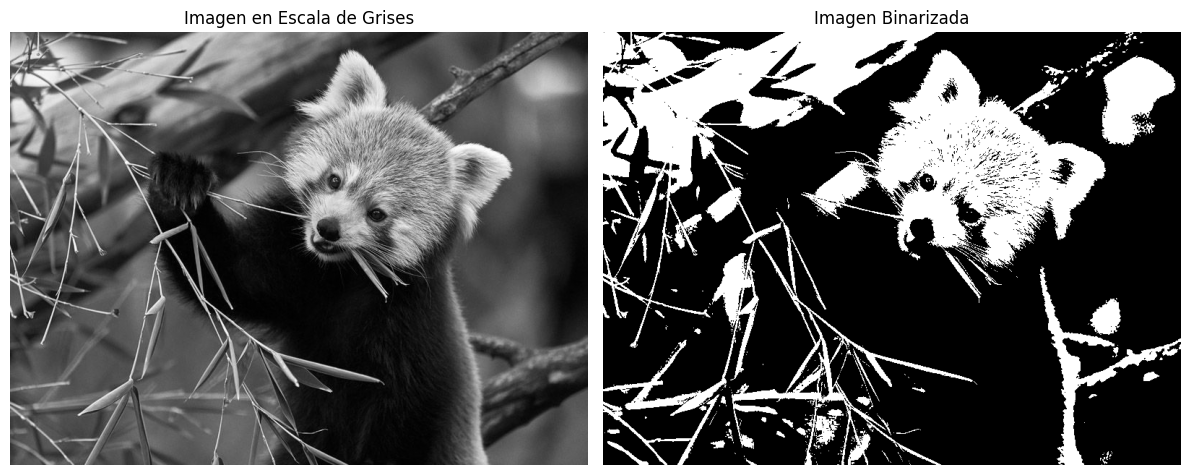

In [7]:
# Binarizar la imagen usando umbralización de Otsu
_, imagen_binaria = cv2.threshold(imagen_gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Visualizar imagen binarizada
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(imagen_gris, cmap='gray')
plt.title('Imagen en Escala de Grises')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_binaria, cmap='gray')
plt.title('Imagen Binarizada')
plt.axis('off')
plt.tight_layout()
plt.show()

### 5.1 Erosión

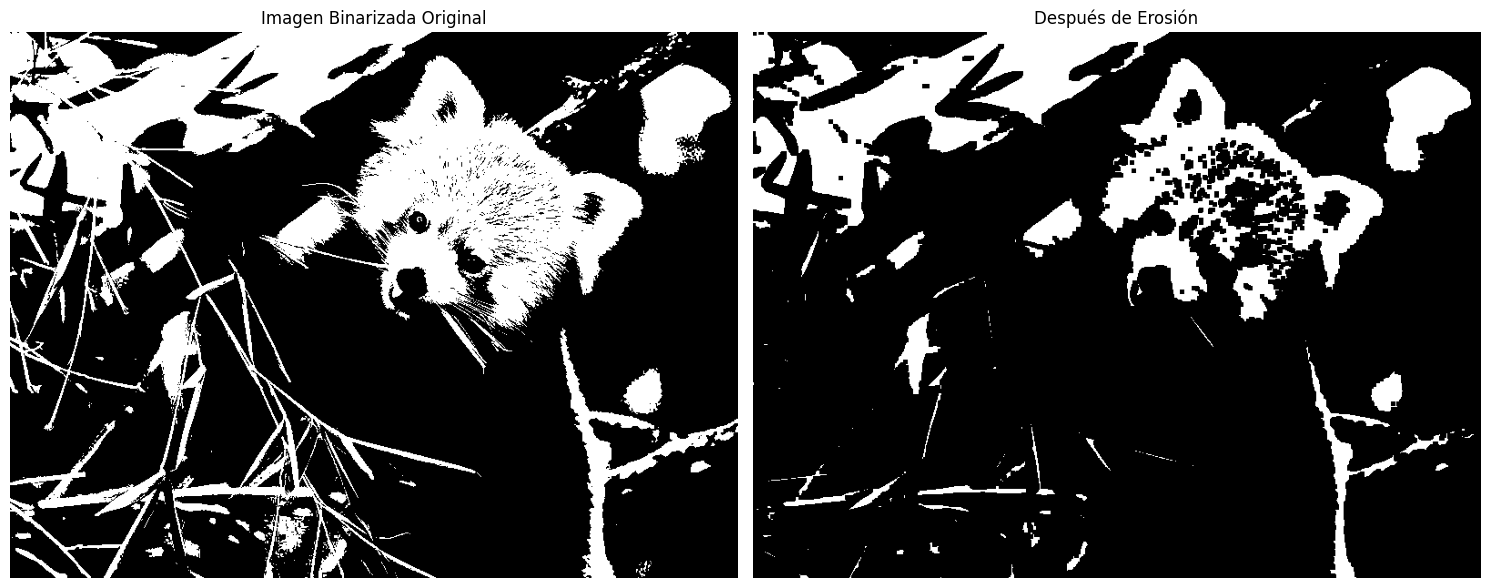

Efecto de la erosión:
La erosión reduce el tamaño de las regiones blancas (primer plano),
eliminando pequeños detalles y ruido. Los bordes de los objetos se adelgazan
y las estructuras pequeñas pueden desaparecer completamente.


In [8]:
# Definir elemento estructurante
kernel = np.ones((5, 5), np.uint8)

# Aplicar erosión
imagen_erosionada = cv2.erode(imagen_binaria, kernel, iterations=1)

# Visualizar resultado
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(imagen_binaria, cmap='gray')
plt.title('Imagen Binarizada Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_erosionada, cmap='gray')
plt.title('Después de Erosión')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Efecto de la erosión:")
print("La erosión reduce el tamaño de las regiones blancas (primer plano),")
print("eliminando pequeños detalles y ruido. Los bordes de los objetos se adelgazan")
print("y las estructuras pequeñas pueden desaparecer completamente.")

### 5.2 Dilatación

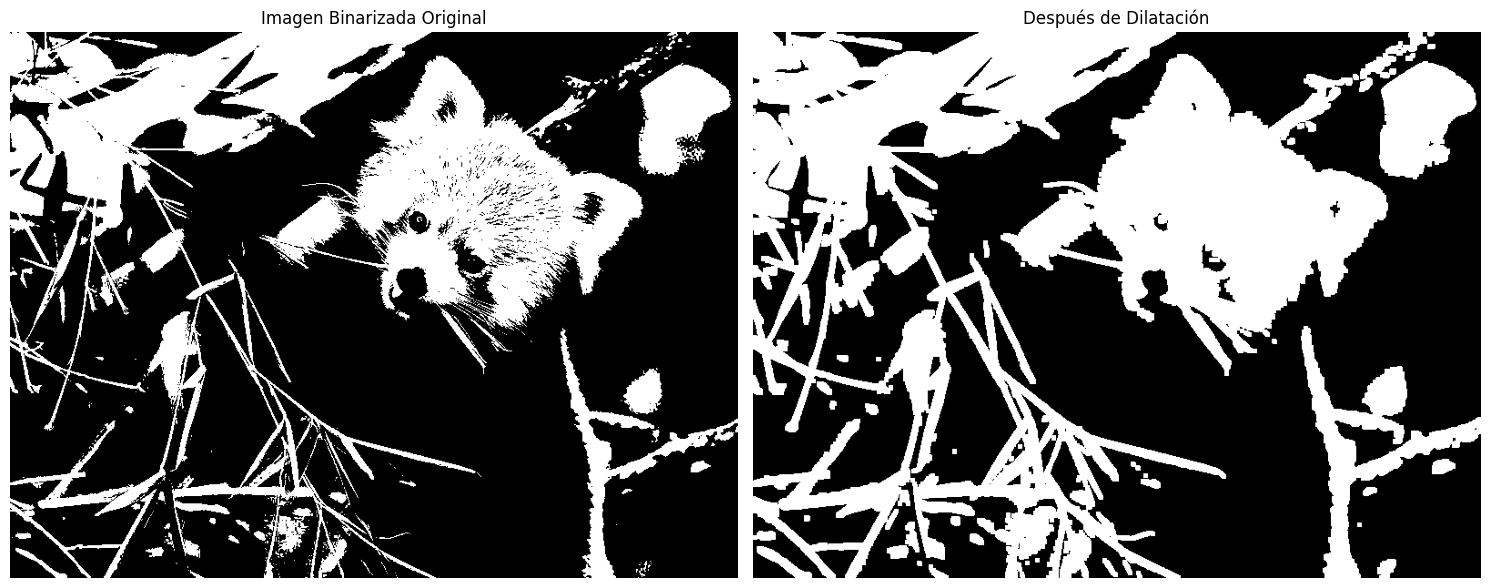

Efecto de la dilatación:
La dilatación expande las regiones blancas (primer plano), rellenando
pequeños huecos y conectando regiones cercanas. Los bordes de los objetos
se engrosan y las estructuras se hacen más prominentes.


In [9]:
# Aplicar dilatación
imagen_dilatada = cv2.dilate(imagen_binaria, kernel, iterations=1)

# Visualizar resultado
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(imagen_binaria, cmap='gray')
plt.title('Imagen Binarizada Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_dilatada, cmap='gray')
plt.title('Después de Dilatación')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Efecto de la dilatación:")
print("La dilatación expande las regiones blancas (primer plano), rellenando")
print("pequeños huecos y conectando regiones cercanas. Los bordes de los objetos")
print("se engrosan y las estructuras se hacen más prominentes.")

## 6. Generación de animación (GIF)

Creamos un GIF que muestra la secuencia de transformaciones aplicadas.

In [10]:
# Preparar frames para el GIF
frames = []

# Función auxiliar para agregar texto a la imagen
def agregar_titulo(imagen, titulo):
    img_con_titulo = imagen.copy()
    if len(img_con_titulo.shape) == 2:  # Si es escala de grises
        img_con_titulo = cv2.cvtColor(img_con_titulo, cv2.COLOR_GRAY2RGB)
    cv2.putText(img_con_titulo, titulo, (30, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)
    return img_con_titulo

# Frame 1: Imagen original
frame1 = agregar_titulo(imagen_rgb, 'Original')
frames.extend([frame1] * 15)  # Mantener por 15 frames

# Frame 2: Imagen suavizada
frame2 = agregar_titulo(imagen_suavizada, 'Suavizado')
frames.extend([frame2] * 15)

# Frame 3: Bordes
bordes_rgb = cv2.cvtColor(bordes, cv2.COLOR_GRAY2RGB)
frame3 = agregar_titulo(bordes_rgb, 'Bordes (Canny)')
frames.extend([frame3] * 15)

# Frame 4: Imagen binarizada
binaria_rgb = cv2.cvtColor(imagen_binaria, cv2.COLOR_GRAY2RGB)
frame4 = agregar_titulo(binaria_rgb, 'Binarizada')
frames.extend([frame4] * 15)

# Frame 5: Erosión
erosion_rgb = cv2.cvtColor(imagen_erosionada, cv2.COLOR_GRAY2RGB)
frame5 = agregar_titulo(erosion_rgb, 'Erosion')
frames.extend([frame5] * 15)

# Frame 6: Dilatación
dilatacion_rgb = cv2.cvtColor(imagen_dilatada, cv2.COLOR_GRAY2RGB)
frame6 = agregar_titulo(dilatacion_rgb, 'Dilatacion')
frames.extend([frame6] * 15)

# Guardar GIF
imageio.mimsave('gifs/procesamiento_imagen.gif', frames, fps=10)
print("GIF generado exitosamente en: gifs/procesamiento_imagen.gif")

GIF generado exitosamente en: gifs/procesamiento_imagen.gif


### Crear GIF: Comparación de filtros

In [13]:
# GIF mostrando antes y después de filtros
frames_filtros = []

# Alternar entre original y filtros
for _ in range(3):
    frames_filtros.extend([agregar_titulo(imagen_rgb, 'Original')] * 10)
    frames_filtros.extend([agregar_titulo(imagen_suavizada, 'Suavizado')] * 10)
    frames_filtros.extend([agregar_titulo(bordes_rgb, 'Bordes')] * 10)

imageio.mimsave('gifs/filtros_comparacion.gif', frames_filtros, fps=10)
print("GIF de filtros generado: gifs/filtros_comparacion.gif")

GIF de filtros generado: gifs/filtros_comparacion.gif


### Crear GIF: Operaciones morfológicas

In [14]:
# GIF mostrando operaciones morfológicas
frames_morfologia = []

for _ in range(3):
    frames_morfologia.extend([agregar_titulo(binaria_rgb, 'Binarizada')] * 10)
    frames_morfologia.extend([agregar_titulo(erosion_rgb, 'Erosion')] * 10)
    frames_morfologia.extend([agregar_titulo(dilatacion_rgb, 'Dilatacion')] * 10)

imageio.mimsave('gifs/morfologia_comparacion.gif', frames_morfologia, fps=10)
print("GIF de morfología generado: gifs/morfologia_comparacion.gif")

GIF de morfología generado: gifs/morfologia_comparacion.gif
